Cell 1 — Load the dataset

In [1]:
import sys
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
from pathlib import Path

sys.path.append(str(Path("../src/data").resolve()))
sys.path.append(str(Path("../src/physics").resolve()))

from dataset import load_dataset

train_ds, val_ds, test_ds, metadata = load_dataset("../data/heat_dataset.npz")

# also load raw numpy arrays for statistical analysis
# (easier than working through the PyTorch Dataset wrapper)
raw = np.load("../data/heat_dataset.npz")

train_inp = raw["train_inputs"]    # (8000, 64, 64)
train_tgt = raw["train_targets"]   # (8000, 64, 64)
val_inp   = raw["val_inputs"]      # (1000, 64, 64)
val_tgt   = raw["val_targets"]     # (1000, 64, 64)
test_inp  = raw["test_inputs"]     # (1000, 64, 64)
test_tgt  = raw["test_targets"]    # (1000, 64, 64)

print("Metadata:")
for k, v in metadata.items():
    print(f"  {k:35s} = {v}")

Dataset loaded successfully.
  Train : 8000 samples
  Val   : 1000 samples
  Test  : 1000 samples
  Input shape per sample : torch.Size([1, 64, 64])
  Metadata: {'n_samples': 10000, 'N': 64, 'L': 1.0, 'alpha': 0.01, 'dx': 0.015873015873015872, 'dt': 0.005668934240362811, 'r': 0.22499999999999998, 'stride': 10, 'seed': 42, 'max_blobs': 3, 'n_train': 8000, 'n_val': 1000, 'n_test': 1000, 'physical_dt_per_cnn_step': 0.05668934240362811}
Metadata:
  n_samples                           = 10000
  N                                   = 64
  L                                   = 1.0
  alpha                               = 0.01
  dx                                  = 0.015873015873015872
  dt                                  = 0.005668934240362811
  r                                   = 0.22499999999999998
  stride                              = 10
  seed                                = 42
  max_blobs                           = 3
  n_train                             = 8000
  n_val             

Cell 2 — Structural checks

In [2]:
print("=" * 55)
print("STRUCTURAL CHECKS")
print("=" * 55)

splits = {
    "train_inputs"  : train_inp,
    "train_targets" : train_tgt,
    "val_inputs"    : val_inp,
    "val_targets"   : val_tgt,
    "test_inputs"   : test_inp,
    "test_targets"  : test_tgt,
}

all_passed = True

for name, arr in splits.items():
    has_nan  = np.any(np.isnan(arr))
    has_inf  = np.any(np.isinf(arr))
    in_range = (arr.min() >= 0.0) and (arr.max() <= 1.0 + 1e-5)
    correct_dtype = arr.dtype == np.float32

    status = "✓" if (not has_nan and not has_inf and in_range and correct_dtype) else "✗"
    if status == "✗":
        all_passed = False

    print(f"{status} {name:20s}  "
          f"shape={str(arr.shape):18s}  "
          f"dtype={arr.dtype}  "
          f"min={arr.min():.4f}  "
          f"max={arr.max():.4f}  "
          f"NaN={has_nan}  "
          f"Inf={has_inf}")

print()
if all_passed:
    print("✓ All structural checks passed.")
else:
    print("✗ Some checks FAILED — investigate before training.")

STRUCTURAL CHECKS
✓ train_inputs          shape=(8000, 64, 64)      dtype=float32  min=0.0000  max=1.0000  NaN=False  Inf=False
✓ train_targets         shape=(8000, 64, 64)      dtype=float32  min=0.0000  max=1.0000  NaN=False  Inf=False
✓ val_inputs            shape=(1000, 64, 64)      dtype=float32  min=0.0000  max=1.0000  NaN=False  Inf=False
✓ val_targets           shape=(1000, 64, 64)      dtype=float32  min=0.0000  max=1.0000  NaN=False  Inf=False
✓ test_inputs           shape=(1000, 64, 64)      dtype=float32  min=0.0000  max=1.0000  NaN=False  Inf=False
✓ test_targets          shape=(1000, 64, 64)      dtype=float32  min=0.0000  max=1.0000  NaN=False  Inf=False

✓ All structural checks passed.


Cell 3 — Physical checks

In [3]:
print("=" * 55)
print("PHYSICAL CHECKS")
print("=" * 55)

# Check 1: targets should never be hotter than inputs
# (heat can only flow out through Dirichlet BC, never in)
max_inp = train_inp.max(axis=(1,2))   # shape (8000,) — max per sample
max_tgt = train_tgt.max(axis=(1,2))

hotter = np.sum(max_tgt > max_inp + 1e-5)
print(f"Samples where target hotter than input : {hotter}")
print(f"  (should be 0 for Dirichlet BC)")
assert hotter == 0, "Unphysical: some targets are hotter than their inputs!"
print("✓ Passed.")

# Check 2: boundary values should be zero
# check all four edges of every training input
edges_nonzero_inp = (
    np.any(train_inp[:, 0,  :] != 0) or   # top
    np.any(train_inp[:, -1, :] != 0) or   # bottom
    np.any(train_inp[:, :,  0] != 0) or   # left
    np.any(train_inp[:, :, -1] != 0)      # right
)
edges_nonzero_tgt = (
    np.any(train_tgt[:, 0,  :] != 0) or
    np.any(train_tgt[:, -1, :] != 0) or
    np.any(train_tgt[:, :,  0] != 0) or
    np.any(train_tgt[:, :, -1] != 0)
)
print(f"\nNon-zero boundary in inputs  : {edges_nonzero_inp}  (should be False)")
print(f"Non-zero boundary in targets : {edges_nonzero_tgt}  (should be False)")
assert not edges_nonzero_inp,  "Boundary condition violated in inputs!"
assert not edges_nonzero_tgt,  "Boundary condition violated in targets!"
print("✓ Passed.")

# Check 3: no all-zero samples (degenerate)
zero_samples_inp = np.sum(train_inp.max(axis=(1,2)) == 0)
print(f"\nAll-zero input samples : {zero_samples_inp}  (should be 0)")
assert zero_samples_inp == 0, "Degenerate all-zero inputs found!"
print("✓ Passed.")

# Check 4: mean temperature should decrease from input to target
mean_inp = train_inp.mean()
mean_tgt = train_tgt.mean()
print(f"\nMean temperature — inputs : {mean_inp:.6f}")
print(f"Mean temperature — targets: {mean_tgt:.6f}")
print(f"  (target mean should be lower — heat is escaping through walls)")
assert mean_tgt < mean_inp, "Target mean >= input mean — physically unexpected!"
print("✓ Passed.")

PHYSICAL CHECKS
Samples where target hotter than input : 0
  (should be 0 for Dirichlet BC)
✓ Passed.

Non-zero boundary in inputs  : False  (should be False)
Non-zero boundary in targets : False  (should be False)
✓ Passed.

All-zero input samples : 0  (should be 0)
✓ Passed.

Mean temperature — inputs : 0.076201
Mean temperature — targets: 0.074962
  (target mean should be lower — heat is escaping through walls)
✓ Passed.


Cell 4 — Distribution analysis

DISTRIBUTION ANALYSIS


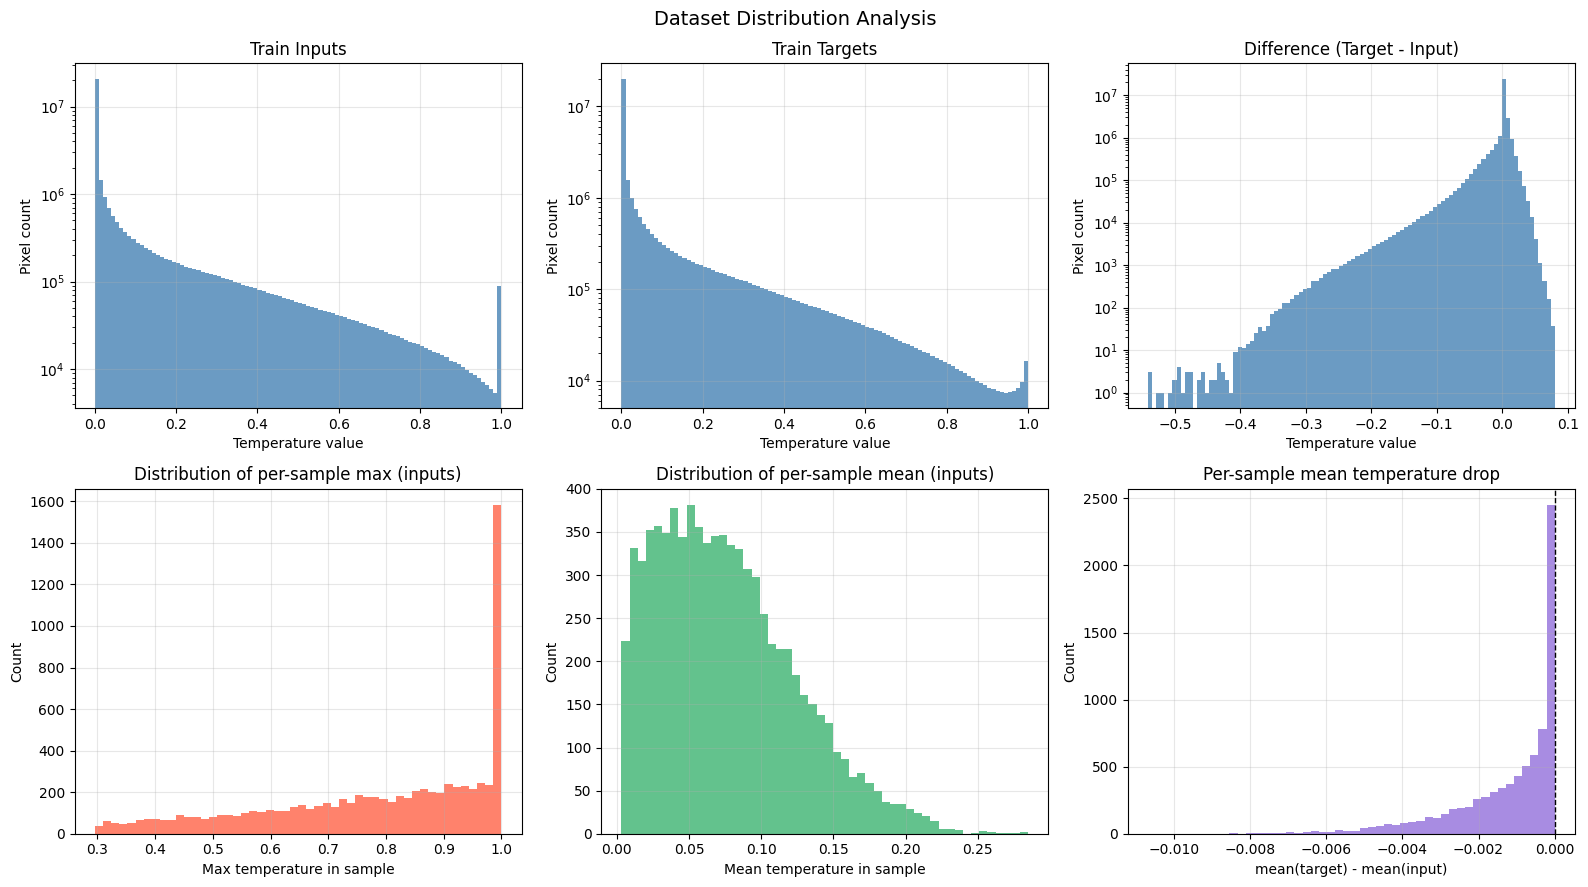


Per-sample max input  : mean=0.7823  std=0.1965  min=0.2956  max=1.0000
Mean temperature drop : mean=-0.001239  std=0.001438


In [4]:
print("=" * 55)
print("DISTRIBUTION ANALYSIS")
print("=" * 55)

fig, axes = plt.subplots(2, 3, figsize=(16, 9))

# ── Row 1: histogram of pixel values ─────────────────
for ax, arr, label in zip(
    axes[0],
    [train_inp, train_tgt, train_tgt - train_inp],
    ["Train Inputs", "Train Targets", "Difference (Target - Input)"]
):
    ax.hist(arr.flatten(), bins=100, color="steelblue", edgecolor="none", alpha=0.8)
    ax.set_title(label)
    ax.set_xlabel("Temperature value")
    ax.set_ylabel("Pixel count")
    ax.set_yscale("log")   # log scale reveals structure in the tails
    ax.grid(True, alpha=0.3)

# ── Row 2: per-sample statistics ─────────────────────
sample_max_inp = train_inp.max(axis=(1,2))
sample_max_tgt = train_tgt.max(axis=(1,2))
sample_mean_inp = train_inp.mean(axis=(1,2))
delta_mean = train_tgt.mean(axis=(1,2)) - train_inp.mean(axis=(1,2))

axes[1, 0].hist(sample_max_inp, bins=50, color="tomato", alpha=0.8)
axes[1, 0].set_title("Distribution of per-sample max (inputs)")
axes[1, 0].set_xlabel("Max temperature in sample")
axes[1, 0].set_ylabel("Count")
axes[1, 0].grid(True, alpha=0.3)

axes[1, 1].hist(sample_mean_inp, bins=50, color="mediumseagreen", alpha=0.8)
axes[1, 1].set_title("Distribution of per-sample mean (inputs)")
axes[1, 1].set_xlabel("Mean temperature in sample")
axes[1, 1].set_ylabel("Count")
axes[1, 1].grid(True, alpha=0.3)

axes[1, 2].hist(delta_mean, bins=50, color="mediumpurple", alpha=0.8)
axes[1, 2].set_title("Per-sample mean temperature drop")
axes[1, 2].set_xlabel("mean(target) - mean(input)")
axes[1, 2].set_ylabel("Count")
axes[1, 2].axvline(0, color="black", linestyle="--", linewidth=1)
axes[1, 2].grid(True, alpha=0.3)

plt.suptitle("Dataset Distribution Analysis", fontsize=14)
plt.tight_layout()
plt.savefig("../figures/milestone4_distributions.png", dpi=150)
plt.show()

print(f"\nPer-sample max input  : mean={sample_max_inp.mean():.4f}  "
      f"std={sample_max_inp.std():.4f}  "
      f"min={sample_max_inp.min():.4f}  "
      f"max={sample_max_inp.max():.4f}")
print(f"Mean temperature drop : mean={delta_mean.mean():.6f}  "
      f"std={delta_mean.std():.6f}")

Cell 5 — Visual inspection of random samples

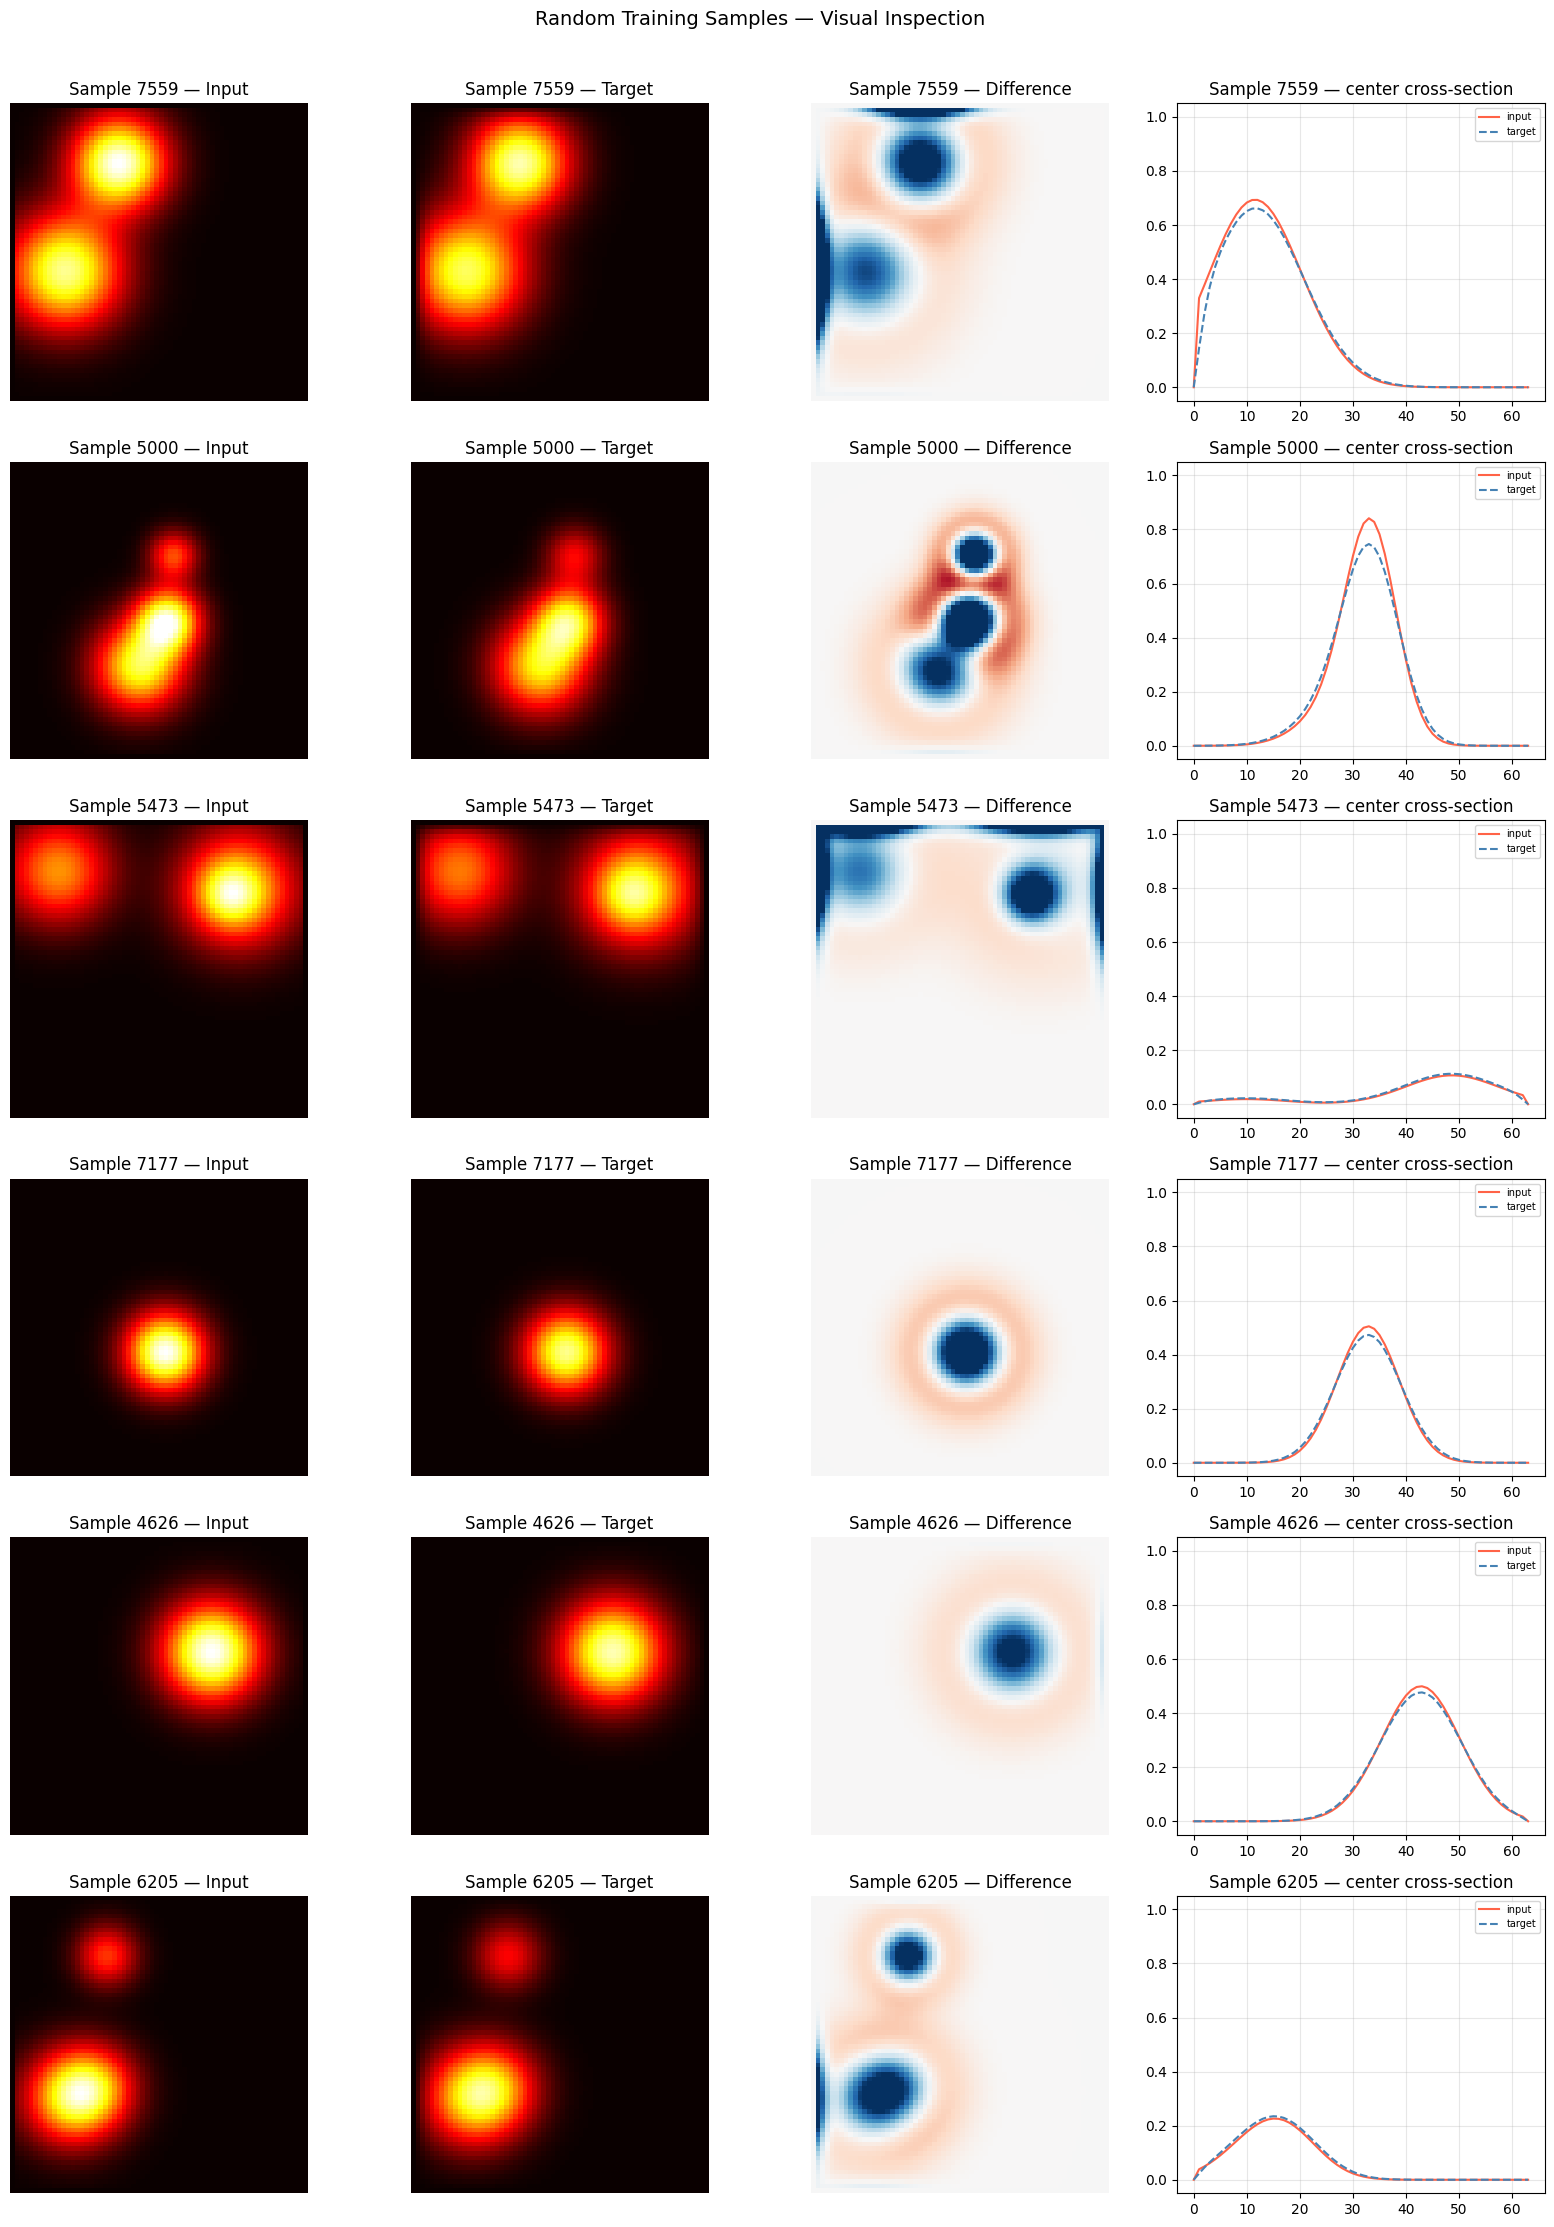

In [5]:
rng_vis = np.random.default_rng(7)
indices  = rng_vis.integers(0, len(train_inp), size=6)

fig, axes = plt.subplots(6, 4, figsize=(16, 22))

for row, idx in enumerate(indices):
    inp  = train_inp[idx]
    tgt  = train_tgt[idx]
    diff = tgt - inp

    # use consistent color scale for input/target comparison
    vmin, vmax = 0.0, max(inp.max(), tgt.max())

    im0 = axes[row, 0].imshow(inp,  origin="lower", cmap="hot",
                               vmin=vmin, vmax=vmax)
    im1 = axes[row, 1].imshow(tgt,  origin="lower", cmap="hot",
                               vmin=vmin, vmax=vmax)
    im2 = axes[row, 2].imshow(diff, origin="lower", cmap="RdBu_r",
                               vmin=-0.05, vmax=0.05)

    # cross-section through the center row
    center = inp.shape[0] // 2
    axes[row, 3].plot(inp[center, :],  label="input",  color="tomato")
    axes[row, 3].plot(tgt[center, :],  label="target", color="steelblue",
                      linestyle="--")
    axes[row, 3].set_ylim(-0.05, 1.05)
    axes[row, 3].legend(fontsize=7)
    axes[row, 3].grid(True, alpha=0.3)
    axes[row, 3].set_title(f"Sample {idx} — center cross-section")

    axes[row, 0].set_title(f"Sample {idx} — Input")
    axes[row, 1].set_title(f"Sample {idx} — Target")
    axes[row, 2].set_title(f"Sample {idx} — Difference")

    for ax in axes[row, :3]:
        ax.axis("off")

plt.suptitle("Random Training Samples — Visual Inspection", fontsize=14, y=1.01)
plt.tight_layout()
plt.savefig("../figures/milestone4_visual_inspection.png", dpi=150, bbox_inches="tight")
plt.show()

Cell 6 — Split distribution comparison

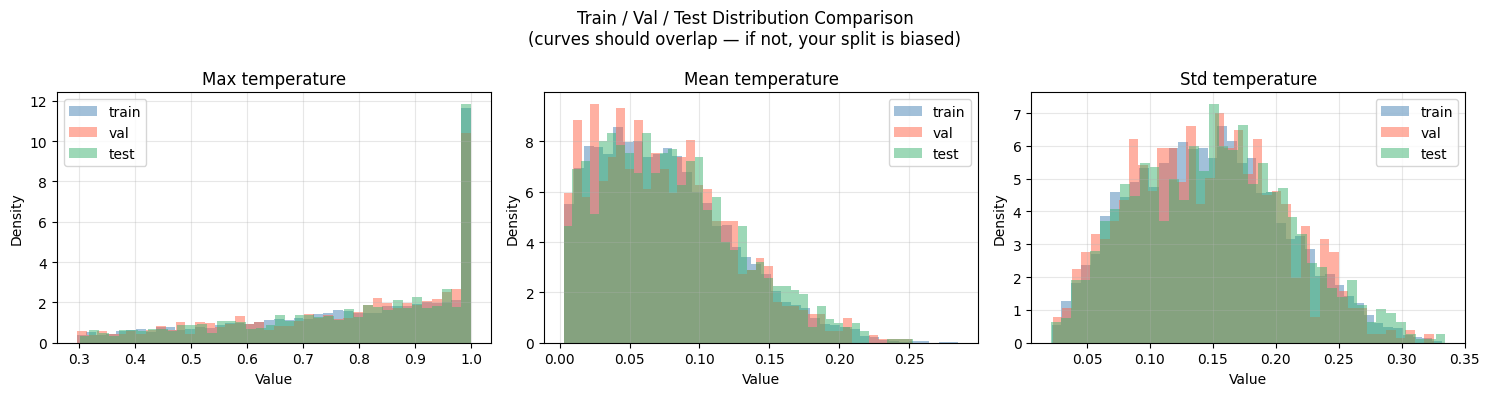

Max temperature       train=0.78232  val=0.78246  test=0.78513  max_diff=0.00281
Mean temperature      train=0.07620  val=0.07571  test=0.07986  max_diff=0.00415
Std temperature       train=0.14628  val=0.14539  test=0.15059  max_diff=0.00520


In [6]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

metrics = {
    "Max temperature"  : lambda x: x.max(axis=(1,2)),
    "Mean temperature" : lambda x: x.mean(axis=(1,2)),
    "Std temperature"  : lambda x: x.std(axis=(1,2)),
}

for ax, (metric_name, metric_fn) in zip(axes, metrics.items()):
    for arr, label, color in [
        (train_inp, "train", "steelblue"),
        (val_inp,   "val",   "tomato"),
        (test_inp,  "test",  "mediumseagreen"),
    ]:
        vals = metric_fn(arr)
        ax.hist(vals, bins=40, alpha=0.5, label=label, color=color, density=True)

    ax.set_title(metric_name)
    ax.set_xlabel("Value")
    ax.set_ylabel("Density")
    ax.legend()
    ax.grid(True, alpha=0.3)

plt.suptitle("Train / Val / Test Distribution Comparison\n"
             "(curves should overlap — if not, your split is biased)", fontsize=12)
plt.tight_layout()
plt.savefig("../figures/milestone4_split_comparison.png", dpi=150)
plt.show()

# numerical check: means should be close across splits
for metric_name, metric_fn in metrics.items():
    t = metric_fn(train_inp).mean()
    v = metric_fn(val_inp).mean()
    s = metric_fn(test_inp).mean()
    print(f"{metric_name:20s}  train={t:.5f}  val={v:.5f}  test={s:.5f}  "
          f"max_diff={max(abs(t-v), abs(t-s), abs(v-s)):.5f}")

Cell 7 — Normalization analysis

In [7]:
print("=" * 55)
print("NORMALIZATION ANALYSIS")
print("=" * 55)

# Your data is already in [0, 1] because:
# - Gaussian amplitude was clipped to [0, 1]
# - Dirichlet BC holds edges at 0
# - Diffusion only reduces temperatures
# So no additional normalization is needed for this project.
# But verify it explicitly:

global_min = train_inp.min()
global_max = train_inp.max()
global_mean = train_inp.mean()
global_std  = train_inp.std()

print(f"Global min  : {global_min:.6f}   (expect 0.0)")
print(f"Global max  : {global_max:.6f}   (expect ~1.0)")
print(f"Global mean : {global_mean:.6f}")
print(f"Global std  : {global_std:.6f}")
print()
print("Since all values are naturally in [0, 1], no rescaling is needed.")
print("The CNN will receive inputs in this range directly.")
print()
print("NOTE for paper: report these statistics in your dataset description.")
print("If you later change alpha or blob parameters, recheck this.")

# save normalization stats for use in training
norm_stats = {
    "global_min"  : float(global_min),
    "global_max"  : float(global_max),
    "global_mean" : float(global_mean),
    "global_std"  : float(global_std),
}
import json
Path("../data/norm_stats.json").write_text(json.dumps(norm_stats, indent=2))
print(f"\n✓ Normalization stats saved to data/norm_stats.json")

NORMALIZATION ANALYSIS
Global min  : 0.000000   (expect 0.0)
Global max  : 1.000000   (expect ~1.0)
Global mean : 0.076201
Global std  : 0.165048

Since all values are naturally in [0, 1], no rescaling is needed.
The CNN will receive inputs in this range directly.

NOTE for paper: report these statistics in your dataset description.
If you later change alpha or blob parameters, recheck this.

✓ Normalization stats saved to data/norm_stats.json


Cell 8 — Summary report

In [8]:
print("=" * 55)
print("MILESTONE 4 — EDA SUMMARY REPORT")
print("=" * 55)
print(f"Total samples         : 10,000")
print(f"Train / Val / Test    : 8000 / 1000 / 1000")
print(f"Grid resolution       : 64 x 64")
print(f"Input dtype           : float32")
print(f"Value range           : [0.0, 1.0]")
print(f"Boundary values       : exactly 0.0 (Dirichlet BC confirmed)")
print(f"NaN / Inf             : none found")
print(f"Degenerate samples    : none found")
print(f"Physically consistent : targets always cooler than inputs")
print(f"Split distribution    : train/val/test consistent")
print(f"Normalization needed  : NO — data naturally in [0, 1]")
print()
print("Dataset is clean and ready for neural network training.")
print("Proceed to Milestone 5.")

MILESTONE 4 — EDA SUMMARY REPORT
Total samples         : 10,000
Train / Val / Test    : 8000 / 1000 / 1000
Grid resolution       : 64 x 64
Input dtype           : float32
Value range           : [0.0, 1.0]
Boundary values       : exactly 0.0 (Dirichlet BC confirmed)
NaN / Inf             : none found
Degenerate samples    : none found
Physically consistent : targets always cooler than inputs
Split distribution    : train/val/test consistent
Normalization needed  : NO — data naturally in [0, 1]

Dataset is clean and ready for neural network training.
Proceed to Milestone 5.
